<a href="https://colab.research.google.com/github/brendanpshea/database_sql/blob/main/Database_12_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SQLite Database Final Project: Design, Implementation, and Optimization

**Note: To start working on this project, you should choose File: "Save Copy in Drive" and then name the file whatever you want. Then, you can type your answers directly into the document.**

Welcome to your final project for the Database and SQL course. In this assignment, you will apply what you have learned about database design, SQL, and optimization to a topic of your choice.

You will design, populate, query, and optimize a SQLite database in Google Colab using the SQL magic extension.

## Learning Outcomes

By the end of this project, you will be able to:

1. Translate a real-world topic into business rules, entities, attributes, and relationships
2. Build a normalized SQLite schema with appropriate keys and data types
3. Populate tables with realistic sample data
4. Write SQL queries that demonstrate filtering, joins, aggregation, and analysis
5. Explain your design decisions, testing approach, and optimization choices clearly

**Aim for a project that takes roughly 6 to 9 hours to complete: challenging enough to be meaningful, but still manageable.**

## Sample Project Ideas

Use one of these ideas or invent your own:

1. A music library management system
2. A personal finance tracker
3. A recipe and meal planning database
4. A fitness and workout log
5. A book collection catalog
6. A plant care and gardening tracker
7. A movie and TV show watchlist
8. A travel planning and itinerary system
9. A collectibles inventory such as trading cards, stamps, or coins
10. A personal learning management system

These are just starting points. Feel free to come up with your own topic.

## Brendan's Lecture

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('https://youtu.be/8ieX7CkuKmc', width=800, height=500)

### Policy on AI Tools
You are allowed to use AI tools (chatGPT, Gemini, Claude, etc.), as these are increasingly important in many areas of database and computer science.

If relevent, please indicate which AI tools did you use in this project. How did they work for you?

[You answer goes here).


## Part 2: Conceptual Modeling - Business Rules

Start by defining the business rules for your chosen database topic. These rules should clearly state the purpose of your database and the relationships between different entities. Write at least 5-7 business rules that govern your database's structure and operations.

Example (for a music library):
1. Each artist can have multiple albums.
2. An album belongs to one primary artist but can feature multiple collaborating artists.
3. Each album contains multiple songs.
4. A song can appear on multiple albums (e.g., original album and compilation).
5. Users can create multiple playlists.
6. A playlist can contain multiple songs, and a song can be in multiple playlists.
7. Each song has one primary genre, but can be associated with multiple subgenres.


### My Answer: Business Rules


## Part 3: Conceptual Modeling - Entities and Attributes

Based on your business rules, identify the main entities in your database and list their attributes. You should have at THREE entities and the attributes should span various data types (INTEGER, TEXT, REAL, BLOB, etc.).

Example (continuing with the music library):

1. Artist
   - ArtistID (INTEGER)
   - Name (TEXT)
   - Country (TEXT)
   - FormedDate (DATE)

2. Album
   - AlbumID (INTEGER)
   - Title (TEXT)
   - ReleaseDate (DATE)
   - ArtistID (INTEGER)
   - CoverArt (BLOB)

3. Song
   - SongID (INTEGER)
   - Title (TEXT)
   - Duration (INTEGER) # in seconds
   - AlbumID (INTEGER)
   - GenreID (INTEGER)

4. Genre
   - GenreID (INTEGER)
   - Name (TEXT)

5. Playlist
   - PlaylistID (INTEGER)
   - Name (TEXT)
   - CreationDate (DATE)

Ensure your entities and attributes adequately represent your chosen topic and align with your business rules.



### My Answer: Entities and Attributes

Write your answer below.

## Part 4: Conceptual Modeling - Entity Relationship Diagram (ERD)

Create an Entity Relationship Diagram (ERD) using Mermaid syntax. This diagram should visually represent the entities you've identified and show the relationships between them. Include cardinality in your diagram (one-to-one, one-to-many, many-to-many).

Here's an example of how to start your Mermaid ERD:

```text
erDiagram
    ARTIST ||--o{ ALBUM : creates
    ALBUM ||--o{ SONG : contains
    SONG }o--|| GENRE : belongs_to
    PLAYLIST }o--o{ SONG : includes
```

Complete the diagram for all entities in your database. Make sure the relationships accurately reflect your business rules.

### My Answer: ERD Diagram

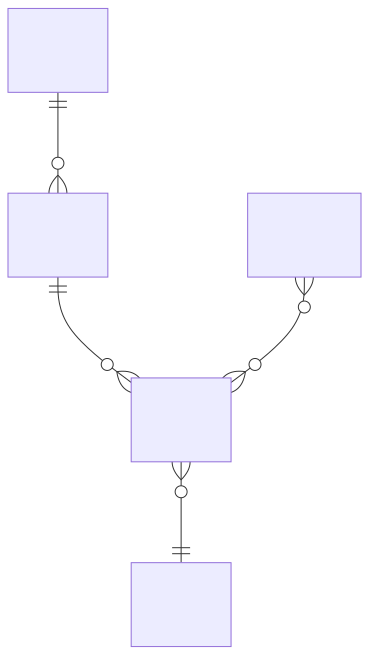

In [3]:
# @title
import base64
import requests
from IPython.display import SVG, display

def mm(graph: str) -> None:
    """
    Fetch and display a Mermaid diagram as SVG.

    Parameters:
      graph (str): Mermaid graph definition.
    """
    # 1. Encode the graph to Base64
    b64 = base64.urlsafe_b64encode(graph.encode('utf-8')).decode('ascii')
    # 2. Construct the SVG URL
    url = f'https://mermaid.ink/svg/{b64}'
    # 3. Fetch SVG content
    svg_data = requests.get(url).text
    # 4. Render inline in Jupyter
    display(SVG(data=svg_data))

# Change the code in the """
mm("""
erDiagram
    ARTIST ||--o{ ALBUM : creates
    ALBUM ||--o{ SONG : contains
    SONG }o--|| GENRE : belongs_to
    PLAYLIST }o--o{ SONG : includes
    """)


## Part 5: Logical Modeling - Relational Model

Transform your conceptual model into a logical model using the relational model. List all the tables in your database, including columns, primary keys, and foreign keys. You may use JSON columns for certain complex attributes if appropriate for your design.

Example:

1. **Artist** (ArtistID PK, Name, Country, FormedDate)  
2. **Album** (AlbumID PK, Title, ReleaseDate, ArtistID FK→Artist(ArtistID), CoverArt)  
3. **Song** (SongID PK, Title, Duration, AlbumID FK→Album(AlbumID), GenreID FK→Genre(GenreID))  
4. **Genre** (GenreID PK, Name)  
5. **Playlist** (PlaylistID PK, Name, CreationDate)  
6. **PlaylistSong** (PlaylistID PK FK→Playlist(PlaylistID), SongID PK FK→Song(SongID))  



### My Answer: Logical Model
Type your answer here.

## Part 6: Logical Modeling - Key Selection Rationale

Explain your choices for primary and foreign keys. Discuss why you selected certain attributes as keys and how these choices support data integrity and efficient querying.

Consider addressing the following points:
- Why did you choose certain attributes as primary keys?
- Are your primary keys natural or surrogate keys? Why?
- How do your foreign key relationships enforce referential integrity?
- Did you implement any composite keys? If so, why?


### Part 6: My Answer

## Part 7: Physical Model - Create Simple Tables

Write SQL statements to create a simple version of your tables. At this stage, include only the column names and their data types, without keys or constraints.

Example:

```sql
%%sql
CREATE TABLE Artist (
    ArtistID INTEGER,
    Name TEXT,
    Country TEXT,
    FormedDate DATE
);

CREATE TABLE Album (
    AlbumID INTEGER,
    Title TEXT,
    ReleaseDate DATE,
    ArtistID INTEGER,
    CoverArt BLOB
);

-- Continue with the rest of your tables...
```

Create all the tables in your database using this simple structure.


### My Answer: Create Tables

### First, Create the Database

In [ ]:
%pip install --quiet jupysql
%load_ext sql
%sql sqlite:///my_data.db

In [ ]:
%%sql
SELECT 'Student workspace: add your CREATE TABLE statements here.' AS note;

## Part 8: Physical Model - Drop Tables

Write SQL statements to drop all the tables you've created. This will allow you to easily reset your database if needed.

Example:

```sql
%%sql
DROP TABLE IF EXISTS Artist;
DROP TABLE IF EXISTS Album;
DROP TABLE IF EXISTS Song;
-- Continue with the rest of your tables...
```

Ensure you include DROP statements for all tables in your database.


### My ANswer: Drop Table

In [ ]:
%%sql
SELECT 'Student workspace: add your DROP TABLE statements here.' AS note;

## Part 9: Physical Model - Create Full Tables

Now, create the full version of your tables, including primary keys, foreign keys, and any other constraints (e.g., NOT NULL, UNIQUE, CHECK).

Example:

```sql
%%sql
CREATE TABLE Artist (
    ArtistID INTEGER PRIMARY KEY,
    Name TEXT NOT NULL,
    Country TEXT,
    FormedDate DATE
);

CREATE TABLE Album (
    AlbumID INTEGER PRIMARY KEY,
    Title TEXT NOT NULL,
    ReleaseDate DATE,
    ArtistID INTEGER,
    CoverArt BLOB,
    FOREIGN KEY (ArtistID) REFERENCES Artist(ArtistID)
);

-- Continue with the rest of your tables...
```

Implement all your tables with full constraints.


### My Answer: Create Full Tables

In [ ]:
%%sql
SELECT 'Student workspace: add your full CREATE TABLE statements here.' AS note;

## Part 10: Data Population - Insert Sample Data

Insert sample data into your tables. Use a mix of direct INSERT statements and, where appropriate, generate data using AI tools.

Example:

```sql
INSERT INTO Artist (Name, Country, FormedDate) VALUES
('The Beatles', 'United Kingdom', '1960-08-01'),
('Queen', 'United Kingdom', '1970-06-27'),
('Beyoncé', 'United States', '1997-01-01');

-- Continue with more INSERT statements for all your tables...
```

Provide at least 5-10 rows of sample data for each table in your database.


### My Answer: Data Population

In [ ]:
%%sql
SELECT 'Student workspace: add your sample INSERT statements here.' AS note;

## Part 11: Basic SELECT Queries

Write and execute at least five SELECT queries that demonstrate your understanding of basic SQL operations. These should include:

1. A simple SELECT with a WHERE clause
2. A query using ORDER BY
3. A query using GROUP BY with an aggregate function
4. A query joining two tables
5. A query using a subquery

Example:

```sql
%%sql
-- 1. Simple SELECT with WHERE
SELECT Title, ReleaseDate
FROM Album
WHERE ReleaseDate > '2000-01-01';

-- 2. Query using ORDER BY
SELECT Name, Country
FROM Artist
ORDER BY Country, Name;

-- Continue with the rest of the queries...
```

Explain the purpose and expected output of each query.


### My Answer: Basic SELECT Queries
Create code and text cells below to run and explain your queries.

In [ ]:
%%sql
SELECT 'Student workspace: add your SELECT queries here.' AS note;

## Part 12: Advanced SELECT Queries

Write and execute at least THREE more complex SELECT queries that demonstrate advanced SQL concepts. Possible examples include:

1. A query using a self-join
2. A query using UNION, INTERSECT, or EXCEPT
3. A query using window functions
4. A query using a Common Table Expression (CTE)
5. A query using a subquery
6. A query using a `CASE` statement
7. A query using SQLite functions for math, date, or strings
8. A query for JSON data (if your database has this).

Example:

```sql
%%sql
-- 1. Self-join (assuming we have a 'Collaboration' table)
SELECT a1.Name AS Artist1, a2.Name AS Artist2
FROM Collaboration c
JOIN Artist a1 ON c.Artist1ID = a1.ArtistID
JOIN Artist a2 ON c.Artist2ID = a2.ArtistID;

-- Continue with the rest of the advanced queries...
```
Explain the purpose and impact of each modification query.

### My Answer: Advanced Queries
Create code/text cells below to run and explain your queries.

## Part 14: Index Creation and Analysis

Create at least two indexes on your tables. Then, use the EXPLAIN QUERY PLAN statement to analyze the performance impact of your indexes on relevant queries.

Example:

```sql
%%sql
-- Create an index
CREATE INDEX idx_album_title ON Album(Title);

-- Analyze a query with EXPLAIN QUERY PLAN
EXPLAIN QUERY PLAN
SELECT * FROM Album WHERE Title = 'Abbey Road';
```

Discuss the results of your EXPLAIN QUERY PLAN analysis. How do the indexes affect query performance?


### My Answer: Create Indexes
Create code and text cells below.

## Part 15: View Creation

Create at least two views that could be useful for your database users. Explain the purpose of each view and how it simplifies complex queries.

Example:

```sql
%%sql
CREATE VIEW ArtistAlbumCount AS
SELECT Artist.Name, COUNT(Album.AlbumID) AS AlbumCount
FROM Artist
LEFT JOIN Album ON Artist.ArtistID = Album.ArtistID
GROUP BY Artist.ArtistID;
```

Provide a brief explanation of how each view could be used in practice.


## Part 16: Transaction Management

Write a multi-statement transaction that demonstrates the use of BEGIN, COMMIT, and ROLLBACK. This transaction should perform a series of related operations that need to be executed atomically.

**Note: This won't actually "work" in this environment. However, just write the query as best you can.**

Example:

```sql
%%sql
BEGIN TRANSACTION;

INSERT INTO Album (Title, ArtistID, ReleaseDate) VALUES ('New Album', 1, '2023-08-01');

UPDATE Artist SET AlbumCount = AlbumCount + 1 WHERE ArtistID = 1;

-- Simulate a condition that would cause a ROLLBACK
SELECT CASE WHEN (SELECT COUNT(*) FROM Album WHERE ArtistID = 1) > 10
            THEN RAISE(ABORT, 'Too many albums for this artist')
            ELSE 0 END;

COMMIT;
```

Explain the importance of transactions in maintaining data consistency and how your example demonstrates this concept.


### My Answer: Transactions

In [ ]:
%%sql
SELECT 'Student workspace: add your transaction example here.' AS note;

## Parts 17 to 20: Reflection and Future Improvements

Write a brief reflection (300-500 words) on your database project. Address the following points:

1. What were the main challenges you faced during this project?
2. How did you overcome these challenges?
3. What are the strengths of your database design?
4. If you were to continue developing this database, what improvements or additional features would you implement?
5. How has this project enhanced your understanding of database design and SQL?

Your reflection should demonstrate critical thinking about your design choices and the database development process.

## Submission Guidelines

When you are done, download the notebook as an `.ipynb` file and submit that file.

Your submission should include your SQL statements, query results, and explanations.

You will receive full credit as long as you make a legitimate attempt to answer each part of the project.

## Chapter Summary

Use this list as a self-check. After working through the chapter, you should be able to do each of the following:

- You can translate a real-world topic into business rules, entities, attributes, and relationships.
- You can build a normalized SQLite schema with appropriate keys and types.
- You can populate tables with realistic sample data.
- You can write queries demonstrating filtering, joins, aggregation, and analysis.
- You can explain your design, testing, and optimization decisions.

## Glossary

Use this reference while you complete the final project.

- **Business rule:** A concise statement describing how the system should work.
- **Entity:** A real-world object or concept you need to store data about.
- **Attribute:** A property of an entity, such as a name, date, or price.
- **Relationship:** A connection between entities.
- **ERD:** An Entity Relationship Diagram that shows entities, attributes, and relationships.
- **Primary key:** A column that uniquely identifies each row in a table.
- **Foreign key:** A column that points to a related row in another table.
- **Normalization:** Organizing tables to reduce redundancy and improve data integrity.
- **Schema:** The overall structure of the database, including tables, columns, and constraints.
- **DDL:** Data Definition Language commands such as `CREATE TABLE` and `ALTER TABLE`.
- **INSERT:** A SQL statement used to add new rows to a table.
- **SELECT:** A SQL statement used to retrieve data.
- **JOIN:** A way to combine related rows from multiple tables.
- **Aggregate function:** A function such as `COUNT()`, `SUM()`, or `AVG()` that summarizes many rows.
- **Index:** A structure that speeds up data retrieval for common queries.
- **EXPLAIN QUERY PLAN:** A SQLite command that shows how the database plans to run a query.
- **View:** A saved SQL query that behaves like a virtual table.
- **Transaction:** A sequence of operations treated as one unit of work.
- **COMMIT:** Makes the work in a transaction permanent.
- **ROLLBACK:** Undoes the work in a transaction if something goes wrong.